In [3]:
from google.colab import files
uploaded = files.upload()

Saving final_dataset.csv to final_dataset.csv


In [4]:
import pandas as pd

data = pd.read_csv("final_dataset.csv")

print("Shape:", data.shape)
print(data.head())
print("\nTarget distribution:")
print(data["icu_event"].value_counts())

Shape: (229445, 14)
    hadm_id  age gender  Creatinine   WBC  Hemoglobin  Platelet  Lactate  \
0  22595853   52      F         0.3   9.0         0.0      99.0      0.0   
1  22841357   52      F         0.3  14.0         0.0      71.0      0.0   
2  25742920   52      F         0.6  11.0         0.0      95.0      0.0   
3  25022803   19      F         0.0   0.0         0.0       0.0      0.0   
4  27988844   48      F         0.9  21.0         0.0     100.0      0.0   

   Potassium  Sodium diabetes hypertension stroke  icu_event  
0        4.5   137.0    False        False  False      False  
1        5.2   126.0    False        False  False      False  
2        6.6   126.0    False        False  False      False  
3        0.0     0.0    False        False  False      False  
4        4.2   146.0    False        False  False      False  

Target distribution:
icu_event
False    178988
True      50457
Name: count, dtype: int64


In [5]:
data = data.drop(columns=["hadm_id"])

In [6]:
data["icu_event"] = data["icu_event"].astype(int)

In [7]:
data["gender"] = data["gender"].map({"M": 1, "F": 0})

In [8]:
data["gender"].fillna(0, inplace=True)

/tmp/ipython-input-3233790808.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["gender"].fillna(0, inplace=True)


In [9]:
data["diabetes"] = data["diabetes"].astype(str).map({"True":1, "False":0})
data["hypertension"] = data["hypertension"].astype(str).map({"True":1, "False":0})
data["stroke"] = data["stroke"].astype(str).map({"True":1, "False":0})

for col in ["diabetes", "hypertension", "stroke"]:
    data[col] = (
        data[col]
        .astype(str)                      # convert everything to string
        .str.strip()                      # remove spaces
        .map({"True":1, "False":0})       # map values
    )

    data[col] = data[col].fillna(0).astype(int)

In [10]:
X = data.drop(columns=["icu_event"])
y = data["icu_event"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (183556, 12)
Test shape: (45889, 12)


In [12]:
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 3.5472922756775502


In [13]:
print("Column Data Types:")
print(X_train.dtypes)

Column Data Types:
age               int64
gender            int64
Creatinine      float64
WBC             float64
Hemoglobin      float64
Platelet        float64
Lactate         float64
Potassium       float64
Sodium          float64
diabetes          int64
hypertension      int64
stroke            int64
dtype: object


In [14]:
!pip install xgboost

In [15]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None,
              num_parallel_tree=None, ...)

In [16]:
from sklearn.metrics import roc_auc_score, classification_report

probs = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)

auc = roc_auc_score(y_test, probs)

print("ROC-AUC:", auc)
print("\nClassification Report:")
print(classification_report(y_test, preds))

ROC-AUC: 0.8426313576788119

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87     35798
           1       0.54      0.65      0.59     10091

    accuracy                           0.80     45889
   macro avg       0.72      0.75      0.73     45889
weighted avg       0.82      0.80      0.81     45889



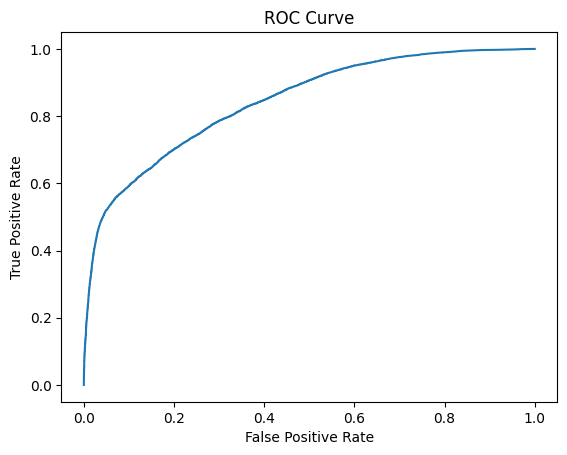

In [17]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, probs)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

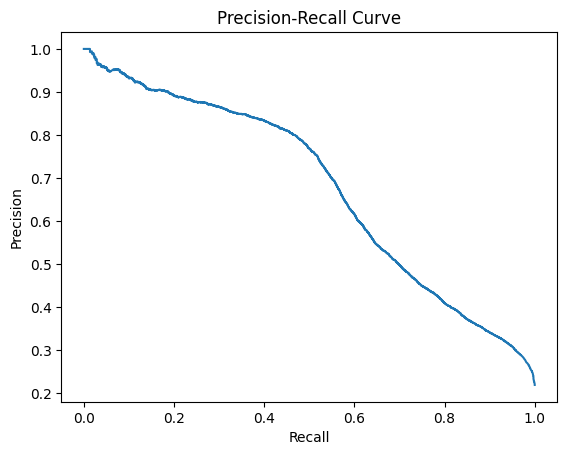

In [18]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

<Figure size 800x600 with 0 Axes>

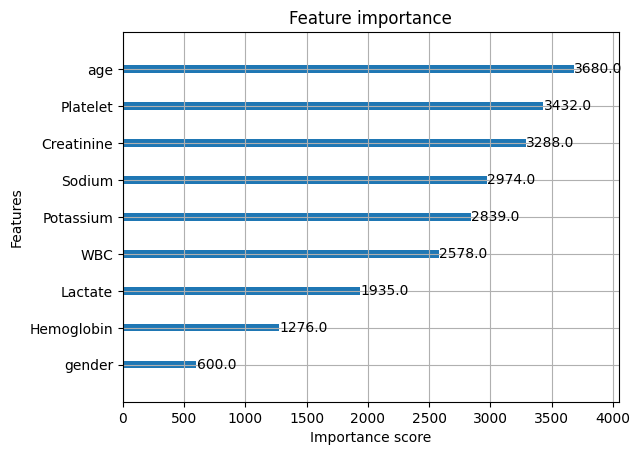

In [19]:
from xgboost import plot_importance

plt.figure(figsize=(8,6))
plot_importance(model)
plt.show()

In [20]:
import joblib

joblib.dump(model, "icu_transfer_xgb.pkl")
joblib.dump(X.columns.tolist(), "feature_order.pkl")

['feature_order.pkl']

In [21]:
files.download("icu_transfer_xgb.pkl")
files.download("feature_order.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>